# 直接反卷积训练（使用真实 PSF）

本 notebook 包含完整的反卷积训练流程，无需外部依赖。
- 使用真实 PSF（25×25 裁剪）
- 跳过去噪，直接训练反卷积
- 包含训练和推理可视化

## 1. 导入依赖

In [11]:
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

print(f"PyTorch: {torch.__version__}")
print(f"CUDA 可用：{torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PyTorch: 2.4.0+cu121
CUDA 可用：True


## 2. 工具函数

In [12]:
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def percentile_norm(x, pmin=0.1, pmax=99.9, eps=1e-8):
    lo = np.percentile(x, pmin)
    hi = np.percentile(x, pmax)
    return np.clip((x - lo) / max(hi - lo, eps), 0.0, 1.0)

def load_image(path):
    arr = np.array(Image.open(path)).astype(np.float32)
    return arr.mean(axis=2) if arr.ndim == 3 else arr

def save_image(path, x):
    x = np.clip(x / max(x.max(), 1e-8), 0.0, 1.0)
    Image.fromarray((x * 65535.0).astype(np.uint16)).save(path)

def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)

def reflect_pad(x, multiple=16, margin=16):
    h, w = x.shape
    new_h = int(math.ceil(h / multiple) * multiple)
    new_w = int(math.ceil(w / multiple) * multiple)
    pad_h, pad_w = max(new_h - h, 0), max(new_w - w, 0)
    top, bottom = margin + pad_h // 2, margin + pad_h - pad_h // 2
    left, right = margin + pad_w // 2, margin + pad_w - pad_w // 2
    return np.pad(x, ((top, bottom), (left, right)), mode="reflect"), (top, bottom, left, right)

def crop_pad(x, padinfo, scale=1):
    top, bottom, left, right = [p * scale for p in padinfo]
    h, w = x.shape
    return x[top:h - bottom, left:w - right]

## 3. PSF 加载

PSF 形状：(25, 25), 总和：1.0000


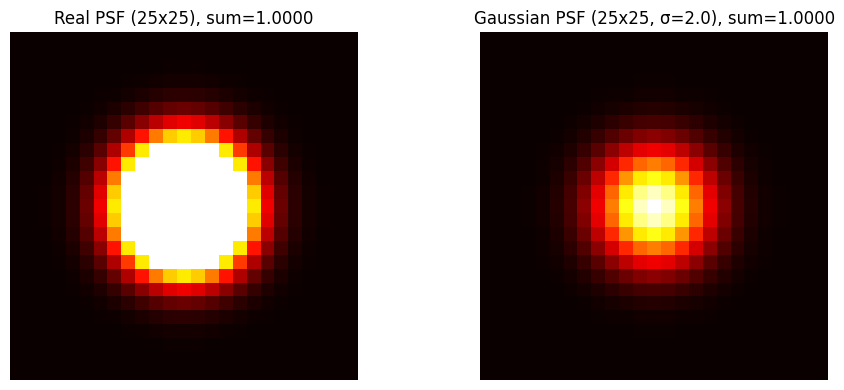

In [13]:
def gaussian_psf(size=25, sigma=2.0):
    if size % 2 == 0:
        size += 1
    r = size // 2
    y, x = np.mgrid[-r:r + 1, -r:r + 1]
    psf = np.exp(-(x ** 2 / (2 * sigma ** 2) + y ** 2 / (2 * sigma ** 2)))
    psf = psf.astype(np.float32)
    psf /= np.maximum(psf.sum(), 1e-8)
    return psf

def load_psf_from_file(psf_path, size=25):
    """从文件加载真实 PSF，裁剪中心区域"""
    psf = load_image(psf_path)
    # psf = percentile_norm(psf)  # ❌ 不要用！会截断 PSF
    
    h, w = psf.shape
    center_y, center_x = h // 2, w // 2
    half = size // 2
    
    top = max(0, center_y - half)
    bottom = min(h, center_y + half + 1)
    left = max(0, center_x - half)
    right = min(w, center_x + half + 1)
    
    psf = psf[top:bottom, left:right]
    
    if psf.shape[0] < size or psf.shape[1] < size:
        pad_h = size - psf.shape[0]
        pad_w = size - psf.shape[1]
        psf = np.pad(psf, ((0, pad_h), (0, pad_w)), mode='constant')
    
    psf /= np.maximum(psf.sum(), 1e-8)
    return psf

def make_psf_tensor(mode, img, size=25, sigma=None, device=None, psf_path=None):
    if mode == "load":
        psf_path = psf_path or "datasets/Microtubule/PSF/psf_emLambda525_dxy0.0313_NA1.3.tif"
        psf = load_psf_from_file(psf_path, size)
    elif mode == "estimate":
        sigma = sigma or 2.0
        psf = gaussian_psf(size, sigma)
    else:
        sigma = sigma or 2.0
        psf = gaussian_psf(size, sigma)
    
    psf_t = torch.from_numpy(psf)[None, None].to(device)
    return psf_t / psf_t.sum().clamp_min(1e-8)

# 测试 PSF 加载
psf_test = load_psf_from_file("datasets/Microtubule/PSF/psf_emLambda525_dxy0.0313_NA1.3.tif", 25)
print(f"PSF 形状：{psf_test.shape}, 总和：{psf_test.sum():.4f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(psf_test, cmap="hot")
plt.title(f"Real PSF (25x25), sum={psf_test.sum():.4f}")
plt.axis("off")

psf_gaussian = gaussian_psf(25, sigma=2.75)
plt.subplot(1, 2, 2)
plt.imshow(psf_gaussian, cmap="hot")
plt.title(f"Gaussian PSF (25x25, σ=2.0), sum={psf_gaussian.sum():.4f}")
plt.axis("off")

plt.tight_layout()
plt.savefig("output/psf_kernel.png", dpi=150)
plt.show()

## 4. 数据加载

In [14]:
class PseudoPairDataset(Dataset):
    """从单张图像生成伪配对数据"""
    def __init__(self, img, patch_size=128, n_samples=2000):
        self.img = img
        self.patch_size = patch_size
        self.n_samples = n_samples
        self.h, self.w = img.shape
    
    def __len__(self):
        return self.n_samples
    
    def __getitem__(self, idx):
        h_start = np.random.randint(0, self.h - self.patch_size)
        w_start = np.random.randint(0, self.w - self.patch_size)
        
        patch = self.img[h_start:h_start + self.patch_size, w_start:w_start + self.patch_size]
        
        noisy = patch + np.random.normal(0, 0.1, patch.shape).astype(np.float32)
        noisy = np.clip(noisy, 0, 1)
        
        # 只添加通道维度 (1, H, W)，DataLoader 会自动添加 batch 维度
        return (
            torch.from_numpy(noisy[None]),
            torch.from_numpy(patch[None])
        )

## 5. 模型定义

In [15]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, n_conv=3):
        super().__init__()
        layers = []
        for i in range(n_conv):
            layers.append(nn.Conv2d(in_ch if i == 0 else out_ch, out_ch, 3, padding=1))
            layers.append(nn.ReLU(inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class Encoder(nn.Module):
    def __init__(self, in_ch=1, base_ch=32, depth=4, n_conv=3):
        super().__init__()
        self.blocks = nn.ModuleList()
        self.pools = nn.ModuleList()
        ch = in_ch
        for i in range(depth):
            out_ch = base_ch * (2 ** i)
            self.blocks.append(ConvBlock(ch, out_ch, n_conv))
            self.pools.append(nn.MaxPool2d(2))
            ch = out_ch
        self.out_ch = ch

    def forward(self, x):
        skips = []
        for blk, pool in zip(self.blocks, self.pools):
            x = blk(x)
            skips.append(x)
            x = pool(x)
        return x, skips


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, n_conv=3):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="nearest")
        layers = [nn.Conv2d(in_ch + skip_ch, out_ch, 3, padding=1), nn.ReLU(inplace=True)]
        cur = out_ch
        for _ in range(n_conv - 1):
            next_ch = max(out_ch // 2, 1)
            layers.extend([nn.Conv2d(cur, next_ch, 3, padding=1), nn.ReLU(inplace=True)])
            cur = next_ch
        self.conv = nn.Sequential(*layers)
        self.out_ch = cur

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="nearest")
        return self.conv(torch.cat([x, skip], dim=1))


class UNetStage(nn.Module):
    def __init__(self, in_ch=1, base_ch=32, depth=4, n_conv=3):
        super().__init__()
        self.encoder = Encoder(in_ch, base_ch, depth, n_conv)
        mid_ch = self.encoder.out_ch * 2
        self.mid = nn.Sequential(
            nn.Conv2d(self.encoder.out_ch, mid_ch, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(mid_ch, self.encoder.out_ch, 3, padding=1), nn.ReLU(inplace=True),
        )
        self.decoders = nn.ModuleList()
        cur_ch = self.encoder.out_ch
        for i in reversed(range(depth)):
            skip_ch = base_ch * (2 ** i)
            block = DecoderBlock(cur_ch, skip_ch, skip_ch, n_conv)
            self.decoders.append(block)
            cur_ch = block.out_ch
        self.out_ch = cur_ch

    def forward(self, x):
        x, skips = self.encoder(x)
        x = self.mid(x)
        for dec, skip in zip(self.decoders, reversed(skips)):
            x = dec(x, skip)
        return x


class DirectDeconvNet(nn.Module):
    """直接反卷积网络（无去噪）"""
    def __init__(self, base_ch=32, depth=4, n_conv=3, upsample=True):
        super().__init__()
        self.upsample = upsample
        self.stage2 = UNetStage(1, base_ch, depth, n_conv)
        self.refine1 = nn.Conv2d(self.stage2.out_ch, 128, 3, padding=1)
        self.refine2 = nn.Conv2d(128, 128, 3, padding=1)
        self.out2 = nn.Conv2d(128, 1, 3, padding=1)

    def forward(self, x):
        f2 = self.stage2(x)
        if self.upsample:
            f2 = F.interpolate(f2, scale_factor=2, mode="nearest")
        deconv = F.relu(self.out2(F.relu(self.refine2(F.relu(self.refine1(f2))))))
        return deconv

# 测试模型
model = DirectDeconvNet(base_ch=32, depth=4, n_conv=3, upsample=True).to(device)
x = torch.randn(1, 1, 128, 128).to(device)
y = model(x)
print(f"输入形状：{x.shape} -> 输出形状：{y.shape}")
print(f"模型参数量：{sum(p.numel() for p in model.parameters()):,}")

输入形状：torch.Size([1, 1, 128, 128]) -> 输出形状：torch.Size([1, 1, 256, 256])
模型参数量：6,638,081


## 6. 损失函数

In [16]:
class HessianLoss(nn.Module):
    """Hessian 正则，抑制伪影"""
    def forward(self, x):
        dxx = x[:, :, :, :-2] - 2 * x[:, :, :, 1:-1] + x[:, :, :, 2:]
        dyy = x[:, :, :-2, :] - 2 * x[:, :, 1:-1, :] + x[:, :, 2:, :]
        dxy = x[:, :, 1:, 1:] - x[:, :, :-1, 1:] - x[:, :, 1:, :-1] + x[:, :, :-1, :-1]
        return (dxx.pow(2).mean() + dyy.pow(2).mean() + dxy.pow(2).mean()) / 3.0


class TVLoss(nn.Module):
    """Total Variation 正则"""
    def forward(self, x):
        dx = x[:, :, :, 1:] - x[:, :, :, :-1]
        dy = x[:, :, 1:, :] - x[:, :, :-1, :]
        return dx.pow(2).mean() + dy.pow(2).mean()


class DeconvLoss(nn.Module):
    """反卷积损失：PSF 卷积重建 + 正则"""
    def __init__(self, psf, upsample=True, hess_w=0.02, tv_w=0.0, l1_w=0.0):
        super().__init__()
        self.register_buffer("psf", psf)
        self.upsample = upsample
        self.hess_w, self.tv_w, self.l1_w = hess_w, tv_w, l1_w
        self.hess = HessianLoss()
        self.tv = TVLoss()

    def forward(self, y_true, y_pred):
        k = self.psf.shape[-1]
        pad = k // 2
        y_conv = F.conv2d(F.pad(y_pred, (pad, pad, pad, pad), mode="reflect"), self.psf, padding=0)
        if self.upsample:
            y_conv = F.interpolate(y_conv, size=y_true.shape[-2:], mode="bilinear", align_corners=False)
        
        loss = F.l1_loss(y_conv, y_true)
        if self.hess_w > 0:
            loss = loss + self.hess_w * self.hess(y_pred)
        if self.tv_w > 0:
            loss = loss + self.tv_w * self.tv(y_pred)
        if self.l1_w > 0:
            loss = loss + self.l1_w * y_pred.abs().mean()
        return loss

# 测试损失函数
psf_tensor = make_psf_tensor("load", img, 25, device=device, psf_path="datasets/Microtubule/PSF/psf_emLambda525_dxy0.0313_NA1.3.tif")
loss_fn = DeconvLoss(psf_tensor, upsample=True, hess_w=0.02)

y_true = torch.randn(1, 1, 128, 128).to(device)
y_pred = torch.randn(1, 1, 128, 128).to(device)
loss = loss_fn(y_true, y_pred)
print(f"测试损失：{loss.item():.4f}")

测试损失：0.9158


## 7. 训练函数

In [17]:
def train_direct_deconv(
    image_path="datasets/Microtubule/train_data/01.tif",
    psf_path="datasets/Microtubule/PSF/psf_emLambda525_dxy0.0313_NA1.3.tif",
    out_dir="./output_notebook",
    psf_size=25,
    patch_size=128,
    n_samples=2000,
    batch_size=4,
    epochs=30,
    lr=1e-4,
    lr_step=10,
    lr_gamma=0.5,
    depth=4,
    n_conv=3,
    base_ch=32,
    upsample=True,
    hess_w=0.02,
    tv_w=0.0,
    l1_w=0.0,
    seed=42,
):
    set_seed(seed)
    ensure_dir(out_dir)
    
    print(f"设备：{device}")
    print(f"加载图像：{image_path}")
    img = percentile_norm(load_image(image_path))
    
    print(f"加载 PSF: {psf_path} ({psf_size}x{psf_size})")
    psf = make_psf_tensor("load", img, psf_size, device=device, psf_path=psf_path)
    
    print("创建数据集...")
    dataset = PseudoPairDataset(img, patch_size, n_samples)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    
    print("初始化模型...")
    model = DirectDeconvNet(base_ch, depth, n_conv, upsample).to(device)
    
    optimizer = torch.optim.Adam(
        list(model.stage2.parameters()) +
        [model.refine1.weight, model.refine1.bias] +
        [model.refine2.weight, model.refine2.bias] +
        [model.out2.weight, model.out2.bias],
        lr=lr
    )
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=lr_step, gamma=lr_gamma)
    loss_fn = DeconvLoss(psf, upsample, hess_w, tv_w, l1_w)
    
    best_path = os.path.join(out_dir, "best_deconv.pt")
    best_loss = float("inf")
    history = []
    
    print("=" * 60)
    print(f"开始训练，{epochs} epochs")
    print("=" * 60)
    
    model.train()
    for epoch in range(epochs):
        losses = []
        for inp, gt in loader:
            inp, gt = inp.to(device), gt.to(device)
            deconv = model(inp)
            loss = loss_fn(gt, deconv)
            
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        
        scheduler.step()
        mean_loss = np.mean(losses)
        lr_now = optimizer.param_groups[0]["lr"]
        history.append(mean_loss)
        
        print(f"epoch {epoch+1:03d}/{epochs:03d} | loss={mean_loss:.6f} lr={lr_now:.2e}")
        
        if mean_loss < best_loss:
            best_loss = mean_loss
            torch.save({
                "model": model.state_dict(),
                "psf": psf.cpu(),
                "cfg": {"base_ch": base_ch, "depth": depth, "n_conv": n_conv, "upsample": upsample}
            }, best_path)
    
    psf_np = psf.squeeze().cpu().numpy()
    save_image(os.path.join(out_dir, "psf_used.tif"), psf_np / psf_np.max())
    
    # 绘制损失曲线
    plt.figure(figsize=(8, 4))
    plt.plot(history, 'b-', linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.grid(True, alpha=0.3)
    plt.savefig(os.path.join(out_dir, "loss_curve.png"), dpi=150)
    plt.show()
    
    print(f"\n训练完成！模型已保存：{best_path}")
    return best_path, history

## 8. 推理函数

In [18]:
@torch.no_grad()
def infer_direct_deconv(image_path, checkpoint_path, out_dir="./output_notebook"):
    ensure_dir(out_dir)
    
    print(f"加载模型：{checkpoint_path}")
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    cfg = ckpt["cfg"]
    
    model = DirectDeconvNet(cfg["base_ch"], cfg["depth"], cfg["n_conv"], cfg["upsample"]).to(device)
    model.load_state_dict(ckpt["model"])
    model.eval()
    
    print(f"处理图像：{image_path}")
    img = percentile_norm(load_image(image_path))
    img_pad, padinfo = reflect_pad(img, multiple=2 ** cfg["depth"], margin=16)
    x = torch.from_numpy(img_pad[None, None]).float().to(device)
    
    deconv = model(x)
    
    scale = 2 if cfg["upsample"] else 1
    deconv_np = crop_pad(deconv.squeeze().cpu().numpy(), padinfo, scale=scale)
    
    name = Path(image_path).stem
    deconv_path = os.path.join(out_dir, f"{name}_deconved.tif")
    save_image(deconv_path, percentile_norm(deconv_np))
    
    print(f"反卷积结果：min={deconv_np.min():.4f}, max={deconv_np.max():.4f}")
    print(f"已保存：{deconv_path}")
    
    # 可视化
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap="gray")
    plt.title("Input")
    plt.axis("off")
    
    plt.subplot(1, 2, 2)
    plt.imshow(deconv_np, cmap="gray")
    plt.title("Deconvolved")
    plt.axis("off")
    
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f"{name}_result.png"), dpi=150)
    plt.show()
    
    return deconv_path, deconv_np

## 9. 开始训练

设备：cuda
加载图像：datasets/Microtubule/train_data/01.tif
加载 PSF: datasets/Microtubule/PSF/psf_emLambda525_dxy0.0313_NA1.3.tif (25x25)
创建数据集...
初始化模型...
开始训练，15 epochs
epoch 001/015 | loss=0.085482 lr=1.00e-04
epoch 002/015 | loss=0.061038 lr=1.00e-04
epoch 003/015 | loss=0.060446 lr=1.00e-04
epoch 004/015 | loss=0.060619 lr=1.00e-04
epoch 005/015 | loss=0.060625 lr=1.00e-04
epoch 006/015 | loss=0.060218 lr=1.00e-04
epoch 007/015 | loss=0.059798 lr=1.00e-04
epoch 008/015 | loss=0.059740 lr=1.00e-04
epoch 009/015 | loss=0.058465 lr=1.00e-04
epoch 010/015 | loss=0.057731 lr=5.00e-05
epoch 011/015 | loss=0.057283 lr=5.00e-05
epoch 012/015 | loss=0.057506 lr=5.00e-05
epoch 013/015 | loss=0.057112 lr=5.00e-05
epoch 014/015 | loss=0.057176 lr=5.00e-05
epoch 015/015 | loss=0.057291 lr=5.00e-05


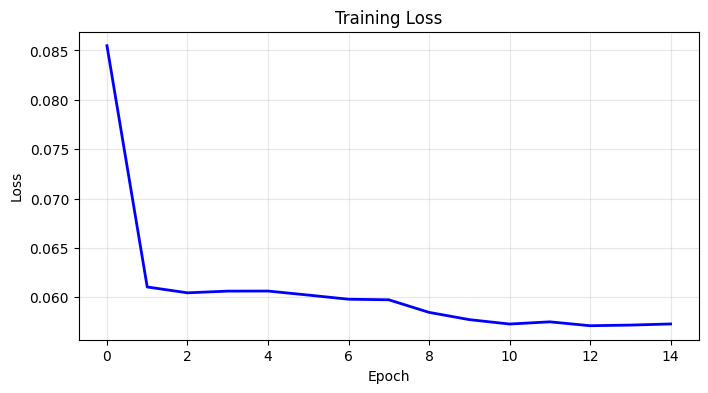


训练完成！模型已保存：./output_notebook/best_deconv.pt


In [23]:
# 训练参数
IMAGE_PATH = "datasets/Microtubule/train_data/01.tif"
PSF_PATH = "datasets/Microtubule/PSF/psf_emLambda525_dxy0.0313_NA1.3.tif"
OUT_DIR = "./output_notebook"

PSF_SIZE = 25
PATCH_SIZE = 128
N_SAMPLES = 2000
BATCH_SIZE = 4

EPOCHS = 30
LR = 1e-4
LR_STEP = 10
LR_GAMMA = 0.5

DEPTH = 4
N_CONV = 3
BASE_CH = 32
UPSAMPLE = True

HESS_W = 0.05
TV_W = 0.0
L1_W = 0.0
SEED = 42

# 开始训练
checkpoint_path, history = train_direct_deconv(
    image_path=IMAGE_PATH,
    psf_path=PSF_PATH,
    out_dir=OUT_DIR,
    psf_size=PSF_SIZE,
    patch_size=PATCH_SIZE,
    n_samples=N_SAMPLES,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LR,
    lr_step=LR_STEP,
    lr_gamma=LR_GAMMA,
    depth=DEPTH,
    n_conv=N_CONV,
    base_ch=BASE_CH,
    upsample=UPSAMPLE,
    hess_w=HESS_W,
    tv_w=TV_W,
    l1_w=L1_W,
    seed=SEED,
)

## 10. 测试推理

加载模型：./output_notebook/best_deconv.pt
处理图像：datasets/Microtubule/train_data/01.tif
反卷积结果：min=0.0000, max=1.8255
已保存：./output_notebook/01_deconved.tif


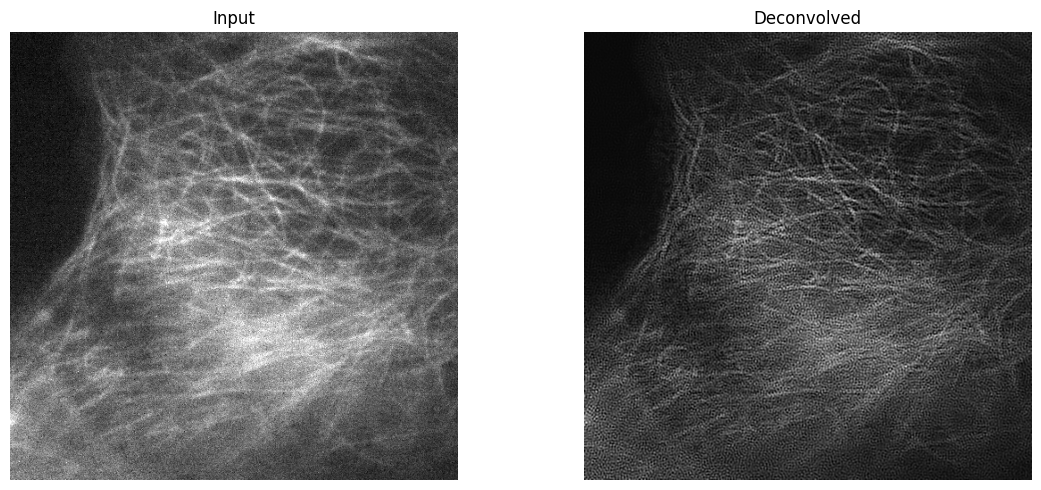

In [24]:
# 使用训练好的模型进行推理
deconv_path, deconv_np = infer_direct_deconv(
    image_path=IMAGE_PATH,
    checkpoint_path=checkpoint_path,
    out_dir=OUT_DIR,
)

## 11. 结果对比

/tmp/ipykernel_458940/1972927587.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


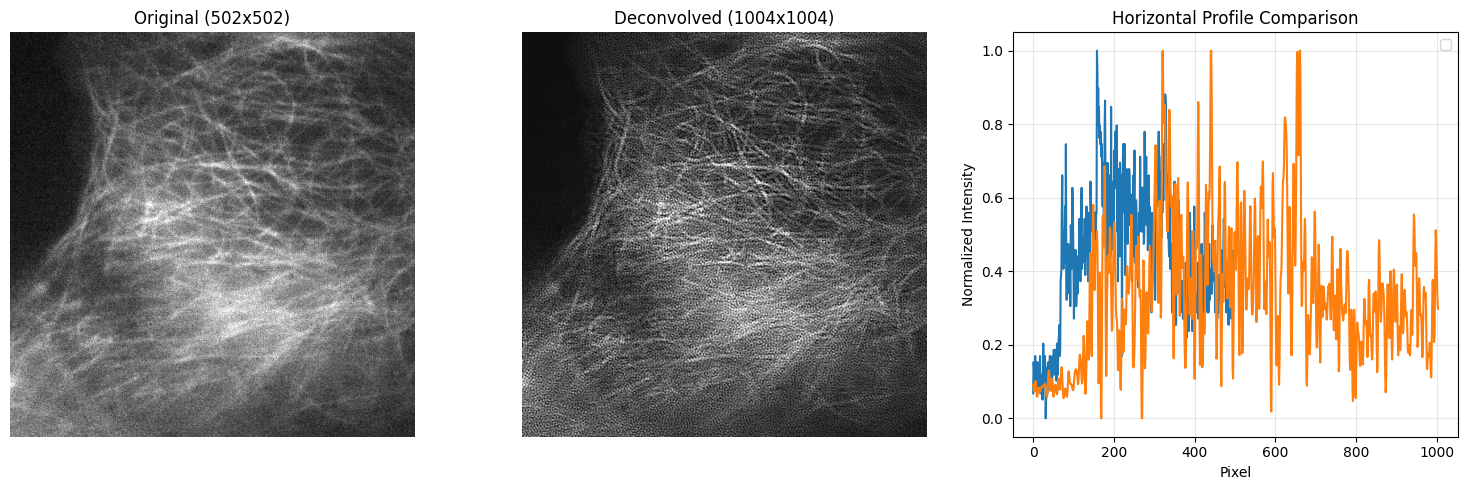

\n所有结果已保存到：./output_notebook


In [26]:
# 加载并对比结果
original = load_image(IMAGE_PATH)
original_norm = percentile_norm(original)
deconv_result = load_image(deconv_path)
deconv_result_norm = percentile_norm(deconv_result)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_norm, cmap="gray")
plt.title(f"Original ({original.shape[0]}x{original.shape[1]})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(deconv_result_norm, cmap="gray")
plt.title(f"Deconvolved ({deconv_result.shape[0]}x{deconv_result.shape[1]})")
plt.axis("off")

# 剖面线对比
center_y = original.shape[0] // 2
x = np.arange(original.shape[1])
plt.subplot(1, 3, 3)
plt.plot(x, original_norm[center_y, :])

# 根据输出尺寸调整剖面线位置
if deconv_result.shape[0] == original.shape[0] * 2:
    # 2x 上采样
    center_y_deconv = center_y * 2
    x_deconv = np.arange(deconv_result.shape[1])
    plt.plot(x_deconv, deconv_result_norm[center_y_deconv, :])
elif deconv_result.shape[0] == original.shape[0]:
    # 无上采样
    plt.plot(x, deconv_result_norm[center_y, :])
else:
    # 其他情况，简单对比中心线
    cy_orig = original_norm.shape[0] // 2
    cy_deconv = deconv_result_norm.shape[0] // 2
    x_deconv = np.arange(deconv_result_norm.shape[1])
    plt.plot(x, original_norm[cy_orig, :])
    plt.plot(x_deconv, deconv_result_norm[cy_deconv, :])

plt.xlabel("Pixel")
plt.ylabel("Normalized Intensity")
plt.title("Horizontal Profile Comparison")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "final_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"\\n所有结果已保存到：{OUT_DIR}")